In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


X, y = make_classification(
    n_samples=3000,      
    n_features=9,      
    n_informative=6,    
    n_redundant=3,       
    n_classes=2,       
    random_state=42
)

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df["target"] = y
print(df.head())

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.025784  -1.591138   2.017812  -1.078964  -2.380355   0.468332   
1  -2.734485  -0.023778   0.854192   1.570324   3.204778   1.779001   
2  -0.743749   0.311015   0.937110  -3.133627  -1.787448   0.823925   
3  -3.046969  -2.389356   2.326755   1.301904   5.643974   2.218527   
4   0.537512  -1.480624   1.583830  -1.023505  -1.776168   0.893815   

   feature_6  feature_7  feature_8  target  
0   2.790267  -1.261553   2.126774       0  
1   0.290141  -0.768989  -0.308120       1  
2   0.864004  -1.684260   0.203090       0  
3   0.142995   0.972990   0.893507       0  
4   2.243206  -0.714071   2.300634       0  


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)


acc = accuracy_score(y_test, y_pred)
print("\nТочність моделі:", acc)


print("\nЗвіт по метриках моделі:\n", classification_report(y_test, y_pred))




Точність моделі: 0.8933333333333333

Звіт по метриках моделі:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89       300
           1       0.87      0.93      0.90       300

    accuracy                           0.89       600
   macro avg       0.90      0.89      0.89       600
weighted avg       0.90      0.89      0.89       600



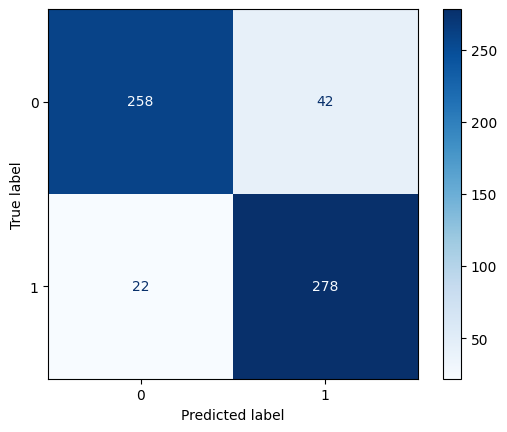

In [9]:

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()